In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from datagen import generate_dynamic_pricing_data

df = generate_dynamic_pricing_data(periods=1000)

df.head()

,timestamp,hour,demand,supply,price,demand_supply_ratio,is_event,moving_avg_demand
0,2026-01-01 00:00:00,0,11,99,99.419011,0.115122,False,11.444153
1,2026-01-01 00:10:00,0,10,94,96.878615,0.109058,False,10.857781
2,2026-01-01 00:20:00,0,11,98,100.587219,0.120589,False,11.195797
3,2026-01-01 00:30:00,0,12,110,99.319033,0.111204,False,11.474872
4,2026-01-01 00:40:00,0,9,105,98.783026,0.088663,False,11.046097


Basic Info about Data

In [9]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            1000 non-null   datetime64[ns]
 1   hour                 1000 non-null   int32         
 2   demand               1000 non-null   int32         
 3   supply               1000 non-null   int32         
 4   price                1000 non-null   float64       
 5   demand_supply_ratio  1000 non-null   float64       
 6   is_event             1000 non-null   bool          
 7   moving_avg_demand    1000 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int32(3)
memory usage: 44.1 KB


,timestamp,hour,demand,supply,price,demand_supply_ratio,moving_avg_demand
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2026-01-04 11:15:00,11.410000,33.482000,99.574000,62.188982,0.359977,33.940882
min,2026-01-01 00:00:00,0.000000,9.000000,57.000000,25.783517,0.088663,10.857781
25%,2026-01-02 17:37:30,5.000000,20.000000,79.000000,45.343241,0.201685,20.879704
50%,2026-01-04 11:15:00,11.000000,31.000000,98.000000,60.589031,0.330630,32.506348
75%,2026-01-06 04:52:30,17.000000,44.000000,118.000000,73.006002,0.491390,44.885890
max,2026-01-07 22:30:00,23.000000,139.000000,209.000000,124.959889,1.108636,68.875681
std,NaN,6.879333,15.754805,23.969837,20.833410,0.187044,14.773514


Time-based Demand

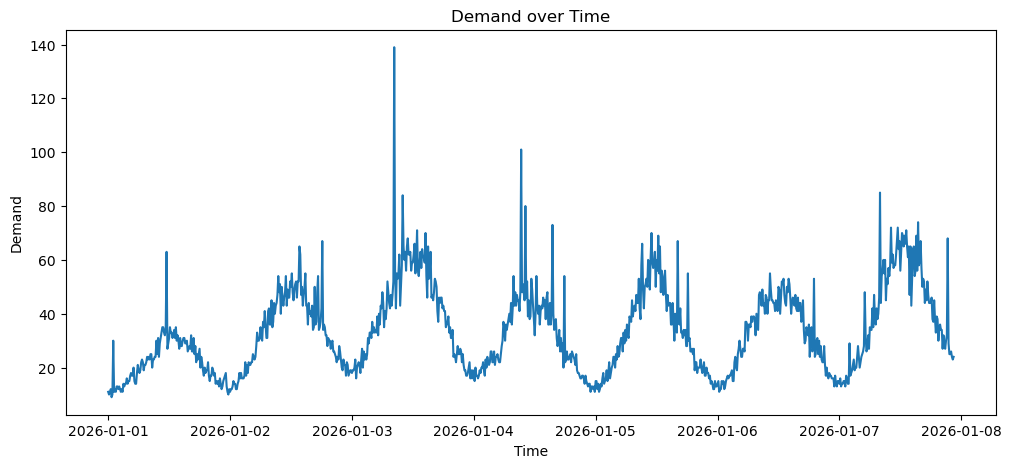

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df["timestamp"], df["demand"])
plt.title("Demand over Time")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.show()

Supply over Time

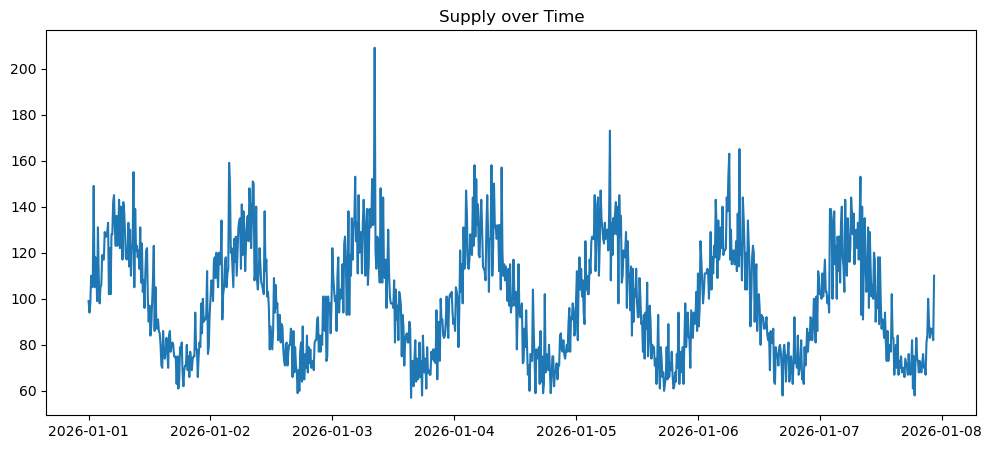

In [20]:
plt.figure(figsize=(12,5))
plt.plot(df["timestamp"], df["supply"])
plt.title("Supply over Time")
plt.show()

Supply over Time

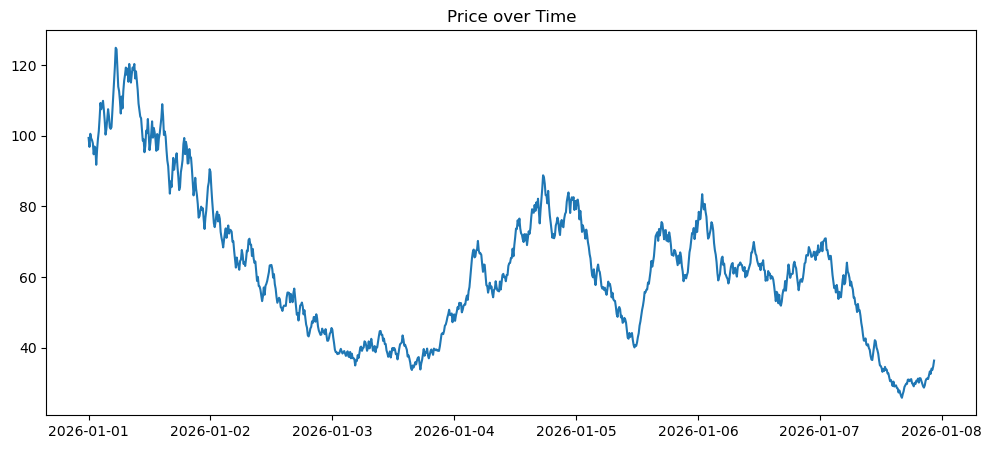

In [12]:
plt.figure(figsize=(12,5))
plt.plot(df["timestamp"], df["price"])
plt.title("Price over Time")
plt.show()

Price vs Demand

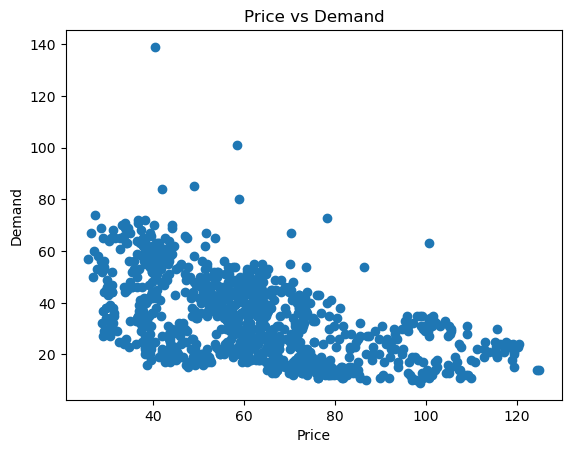

In [13]:
plt.scatter(df["price"], df["demand"])
plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Price vs Demand")
plt.show()

Demand vs Supply

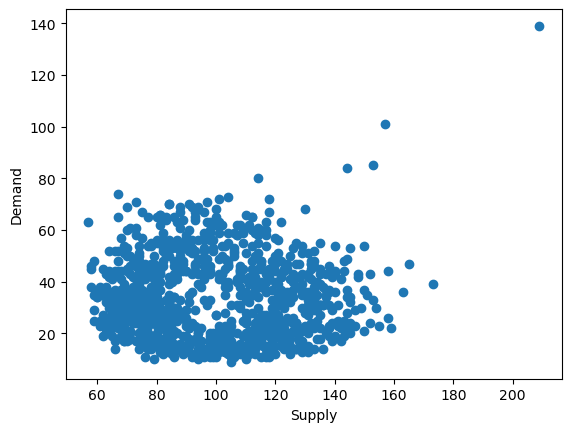

In [14]:
plt.scatter(df["supply"], df["demand"])
plt.xlabel("Supply")
plt.ylabel("Demand")
plt.show()

Demand/Supply Ratio

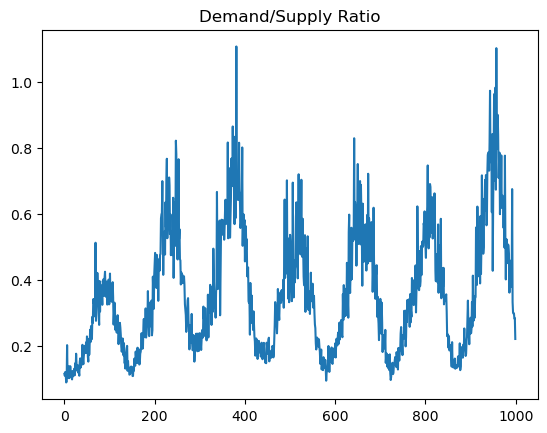

In [15]:
plt.plot(df["demand_supply_ratio"])
plt.title("Demand/Supply Ratio")
plt.show()

Events Impact

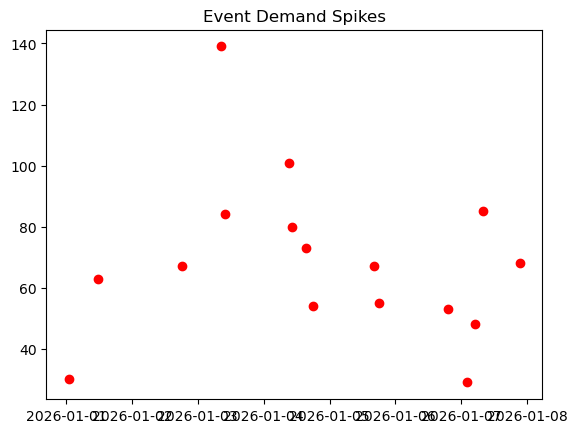

In [16]:
event_df = df[df["is_event"] == 1]

plt.scatter(event_df["timestamp"], event_df["demand"], color='red')
plt.title("Event Demand Spikes")
plt.show()

Moving Average

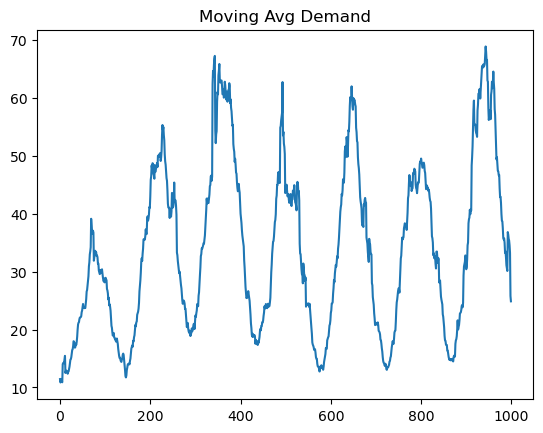

In [17]:
plt.plot(df["moving_avg_demand"])
plt.title("Moving Avg Demand")
plt.show()

Correlation Matrix

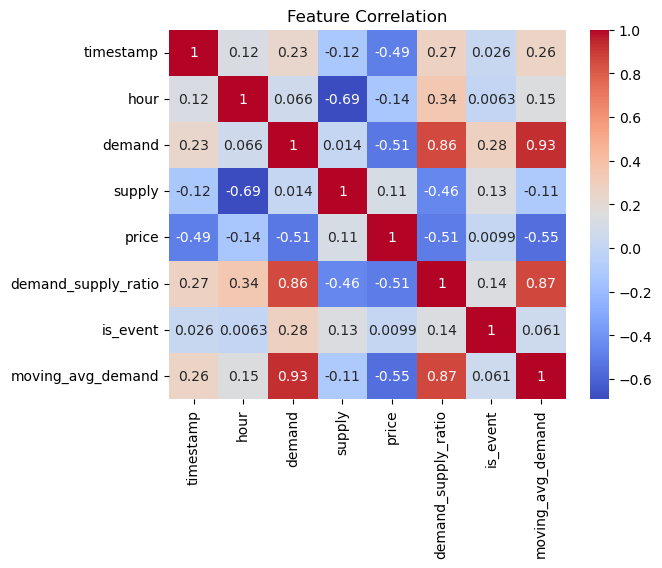

In [18]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Distribution Check

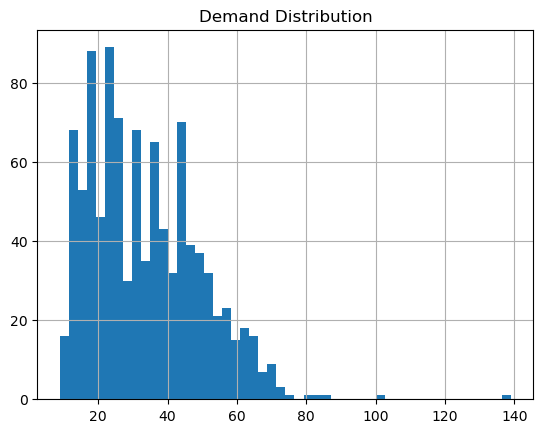

In [19]:
df["demand"].hist(bins=50)
plt.title("Demand Distribution")
plt.show()

Time pattern by hour

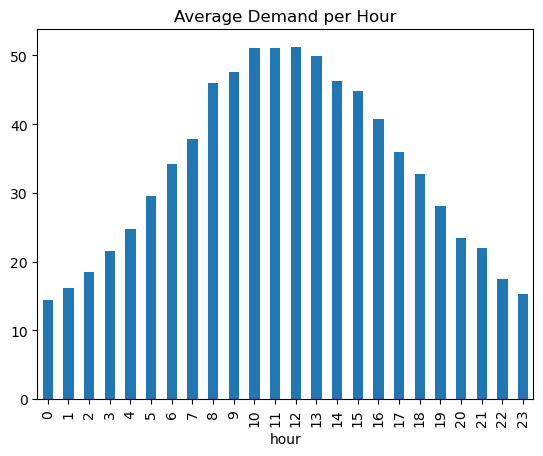

In [21]:
df.groupby("hour")["demand"].mean().plot(kind='bar')
plt.title("Average Demand per Hour")
plt.show()

Event vs Normal comparison

In [22]:
df.groupby("is_event")["demand"].mean()

is_event
False    32.912602
True     68.500000
Name: demand, dtype: float64

Price elasticity

C:\Users\Dhruv Jha\AppData\Local\Temp\ipykernel_13600\2123640300.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_bin")["demand"].mean().plot()


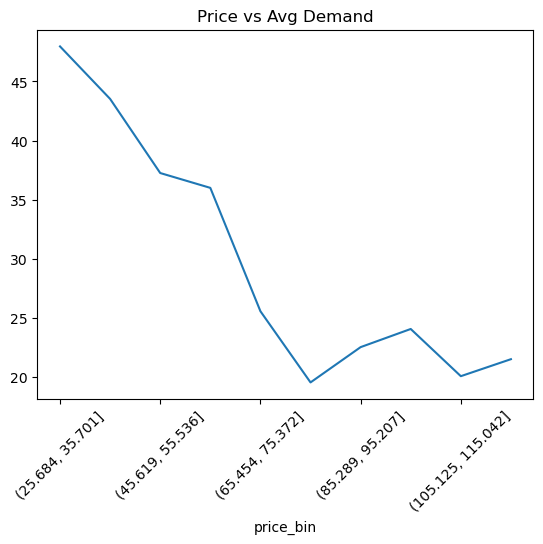

In [23]:
df["price_bin"] = pd.cut(df["price"], bins=10)

df.groupby("price_bin")["demand"].mean().plot()
plt.title("Price vs Avg Demand")
plt.xticks(rotation=45)
plt.show()

Revenue analysis

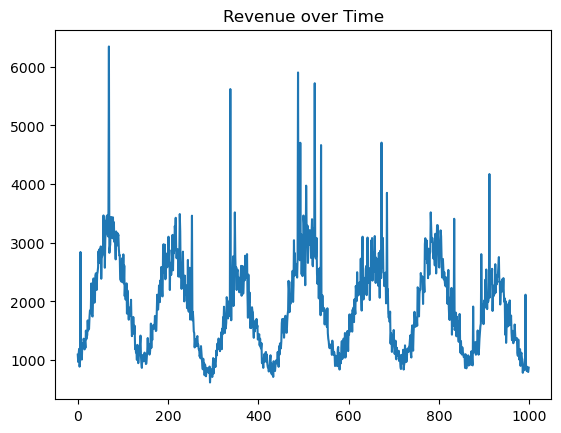

In [25]:
df["revenue"] = df["price"] * df["demand"]

plt.plot(df["revenue"])
plt.title("Revenue over Time")
plt.show()

High demand vs low supply cases

In [26]:
high_stress = df[df["demand_supply_ratio"] > 1.5]

print(high_stress.head())

Empty DataFrame
Columns: [timestamp, hour, demand, supply, price, demand_supply_ratio, is_event, moving_avg_demand, price_bin, revenue]
Index: []


Correlation deep analysis

In [28]:
df.select_dtypes(include=['number']).corr()["demand"].sort_values(ascending=False)

demand                 1.000000
moving_avg_demand      0.932616
demand_supply_ratio    0.855569
revenue                0.689569
hour                   0.066354
supply                 0.014208
price                 -0.514203
Name: demand, dtype: float64

Outliers check

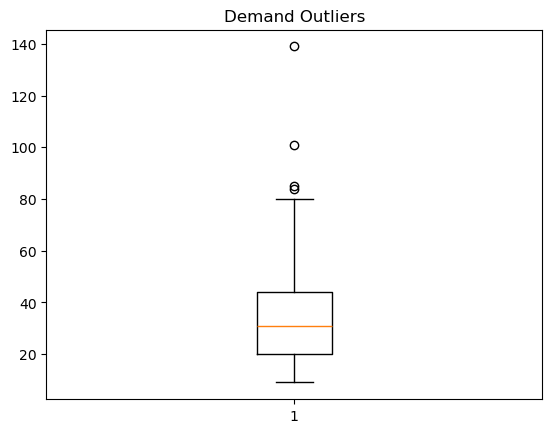

In [29]:
plt.boxplot(df["demand"])
plt.title("Demand Outliers")
plt.show()

Rolling trend comparison

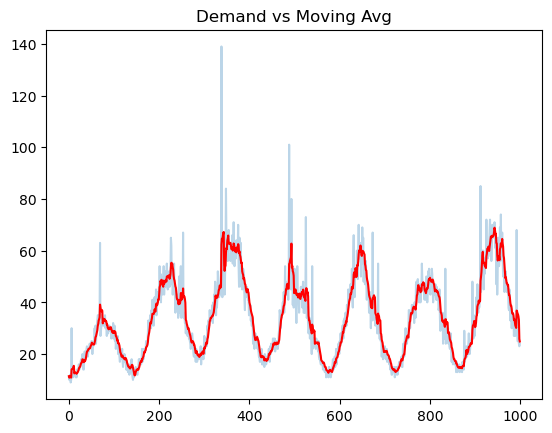

In [30]:
plt.plot(df["demand"], alpha=0.3)
plt.plot(df["moving_avg_demand"], color='red')
plt.title("Demand vs Moving Avg")
plt.show()